In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter, CoxTimeVaryingFitter
from lifelines.utils import concordance_index
from sklearn.metrics import roc_curve, roc_auc_score

In [2]:
fig_dir = "../figures"

In [3]:
df_train_val = pd.read_parquet('../data/data_survival_train_val.parquet')
df_test = pd.read_parquet('../data/data_survival_test.parquet')
print(f"Train/Val: {len(df_train_val):,} | Defaults: {(df_train_val['event']==1).sum():,} | Payinfulls: {(df_train_val['event']==2).sum():,} | Censored: {(df_train_val['event']==0).sum():,}")
print(f"Test: {len(df_test):,} | Defaults: {(df_test['event']==1).sum():,} | Payinfulls: {(df_test['event']==2).sum():,} | Censored: {(df_test['event']==0).sum():,}")

Train/Val: 124,294 | Defaults: 11,612 | Payinfulls: 98,654 | Censored: 14,028
Test: 57,399 | Defaults: 199 | Payinfulls: 11,181 | Censored: 46,019


In [4]:
df_train_val['event_default'] = (df_train_val['event']==1).astype(int)
df_train_val['event_payinfull'] = (df_train_val['event']==2).astype(int)
df_test['event_default'] = (df_test['event']==1).astype(int)
df_test['event_payinfull'] = (df_test['event']==2).astype(int)

## KM Curves

In [5]:
def plot_km_stratified(df, duration_col='duration_days', event_col='event', stratify_col=None,
                       n_bins=5, ax=None, title=None):
    """
    Plot Kaplan-Meier curves stratified by a column.
    - If stratify_col has few unique values (<=15), use as is.
    - If continuous, bin into n_bins quantile groups.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    
    kmf = KaplanMeierFitter()
    
    if stratify_col is None:
        kmf.fit(df[duration_col], df[event_col], label='All')
        kmf.plot_survival_function(ax=ax, ci_show=True)
    else:
        vals = df[stratify_col]
        n_unique = vals.nunique()
        if n_unique > 15 or vals.dtype in ['float64', 'float32']:
            # Bin continuous
            df_plot = df.copy()
            df_plot['_strat'] = pd.qcut(vals, q=n_bins, duplicates='drop', labels=False).astype(str)
            groups = df_plot['_strat'].unique()
        else:
            df_plot = df.copy()
            df_plot['_strat'] = vals.astype(str)
            groups = df_plot['_strat'].dropna().unique()
        
        for g in sorted(groups, key=lambda x: (df_plot[df_plot['_strat']==x][duration_col].median(), str(x))):
            mask = df_plot['_strat'] == g
            if mask.sum() < 10:
                continue
            kmf_g = KaplanMeierFitter()
            kmf_g.fit(df_plot.loc[mask, duration_col], df_plot.loc[mask, event_col], label=f'{stratify_col}={g}')
            kmf_g.plot_survival_function(ax=ax, ci_show=True)
    
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Survival probability')
    ax.set_title(title or f'KM curve' + (f' (stratify: {stratify_col})' if stratify_col else ''))
    ax.legend(loc='lower left')
    ax.grid(True, alpha=0.3)
    return ax

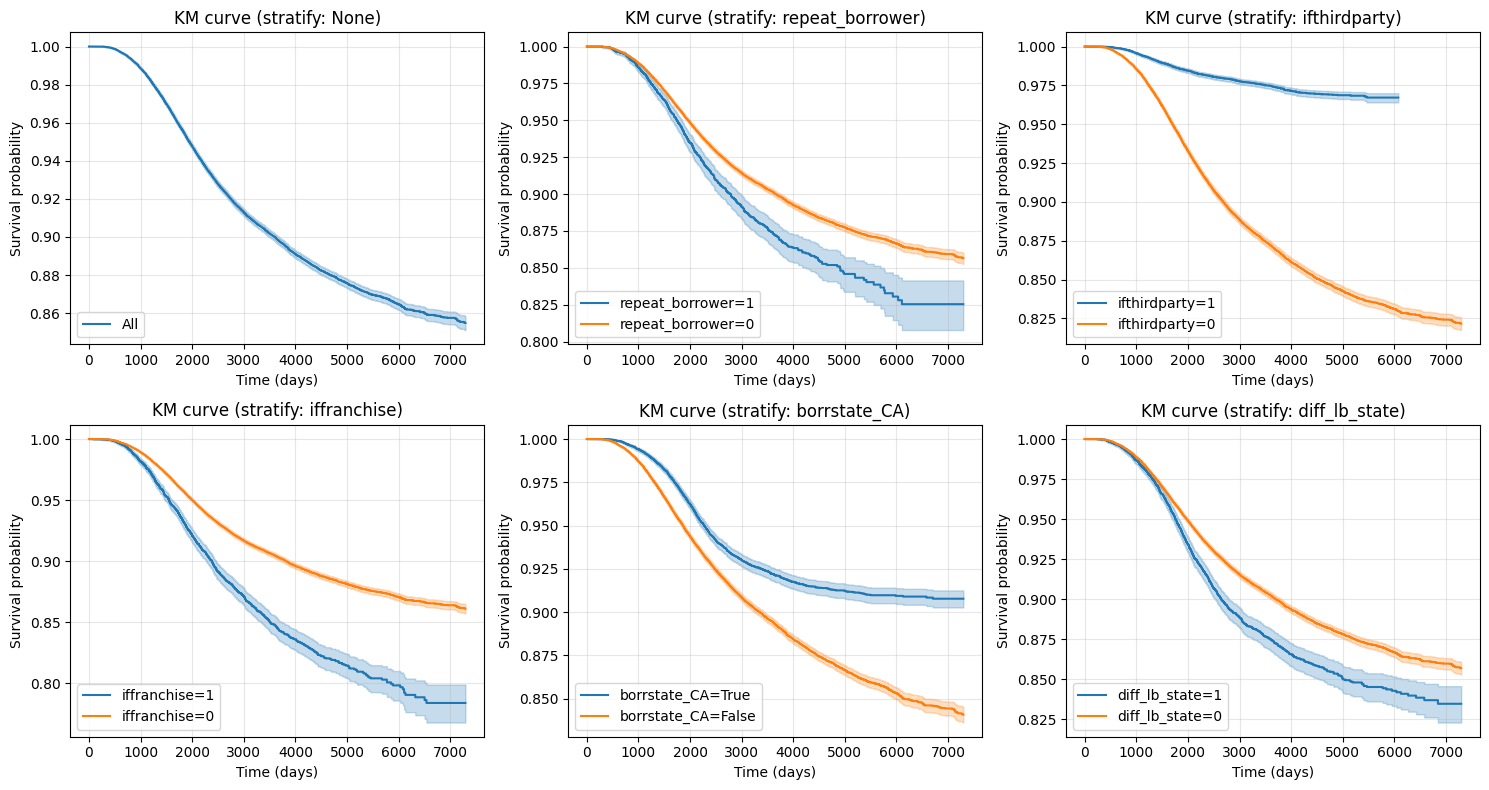

In [6]:
# KM curves: overall and stratified by repeat_borrower, market_stress_m
stratify_cols = [None, 'repeat_borrower', 'ifthirdparty', 'iffranchise', 'borrstate_CA', 'diff_lb_state']

n = len(stratify_cols)
ncols = min(n, 3)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.array(axes).reshape(-1)
for i, stratify_col in enumerate(stratify_cols):
    plot_km_stratified(df_train_val, event_col='event_default', stratify_col=stratify_col, 
    ax=axes[i], title=f'KM curve (stratify: {stratify_col})')

plt.tight_layout()
plt.savefig(f"../figures/KM_curves.png", dpi=300, bbox_inches='tight')
plt.show()

## Static Cox Model

### Time to Default

In [7]:
event_col = 'event_default'

# Cox model: exclude duration, event, default from predictors
exclude = ['duration_days', 'event', 'default', 'event_default', 'event_payinfull']
tv_cols = [col for col in df_train_val.columns if '_m' not in col and '_y' not in col and '_st' not in col]
cox_cols = [c for c in df_train_val.columns if c not in exclude and c in tv_cols]
df_cox = df_train_val[cox_cols + ['duration_days', event_col]].copy()

# Cox model: exclude duration, event, default from predictors
cox_l1 = CoxPHFitter(penalizer=0.01, l1_ratio=1.0)
cox_l1.fit(df_cox, duration_col='duration_days', event_col=event_col)

coef = cox_l1.params_
selected_features = coef[coef.abs() > 1e-5].index.tolist()
print("Selected features:", selected_features)

Selected features: ['ifthirdparty', 'log_grossapproval', 'borrstate_CA', 'borrstate_FL', 'naicscode_44', 'naicscode_62', 'naicscode_72', 'naicscode_Unknown']


In [8]:
df_cox_sel = df_cox[selected_features + ['duration_days', event_col]]

cox_final = CoxPHFitter()
cox_final.fit(df_cox_sel, duration_col='duration_days', event_col=event_col)

cox_final.print_summary()

<lifelines.CoxPHFitter: fitted with 124294 total observations, 112682 right-censored observations>
             duration col = 'duration_days'
                event col = 'event_default'
      baseline estimation = breslow
   number of observations = 124294
number of events observed = 11612
   partial log-likelihood = -128717.15
         time fit was run = 2026-03-23 10:16:57 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
ifthirdparty      -1.78      0.17      0.04           -1.85           -1.71                0.16                0.18
log_grossapproval  0.18      1.20      0.01            0.16            0.20                1.18                1.22
borrstate_CA      -0.40      0.67      0.03           -0.45           -0.34                0.64                0.71
borrstate_FL       0.58      1.79      0.03            0.52            0.65                1.68                1.91
naicscode_44       0.32      1.37      0.03            0.26            0.38                1.29                1.46
naicscode_62      -0.40      0.67      0.04           -0.48           -0.33                0.62                0.72
naicscode_72       0.76      2.14      0.02            0.71            0.81                2.04                2.24
naicscode_Unknown -0.86      0.42      0.03           -0.93           -0.79                0.40                0.45

                   cmp to      z      p  -log2(p)
covariate                                        
ifthirdparty         0.00 -48.97 <0.005       inf
log_grossapproval    0.00  18.87 <0.005    261.48
borrstate_CA         0.00 -14.74 <0.005    160.88
borrstate_FL         0.00  18.06 <0.005    239.73
naicscode_44         0.00  10.55 <0.005     84.10
naicscode_62         0.00 -11.01 <0.005     91.22
naicscode_72         0.00  31.36 <0.005    714.58
naicscode_Unknown    0.00 -24.73 <0.005    446.17
---
Concordance = 0.71
Partial AIC = 257450.29
log-likelihood ratio test = 6825.66 on 8 df
-log2(p) of ll-ratio test = inf

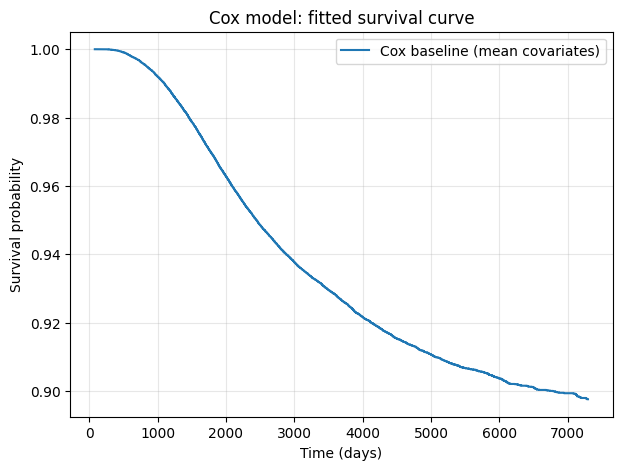

In [9]:
# Fitted survival curve from Cox (baseline = mean covariates)
fig, ax = plt.subplots(figsize=(7, 5))
bs = cox_final.baseline_survival_
ax.step(bs.index, bs.iloc[:, 0], where='post', label='Cox baseline (mean covariates)')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Survival probability')
ax.set_title('Cox model: fitted survival curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig(f"../figures/Cox_survival_curve.png", dpi=300, bbox_inches='tight')
plt.show()

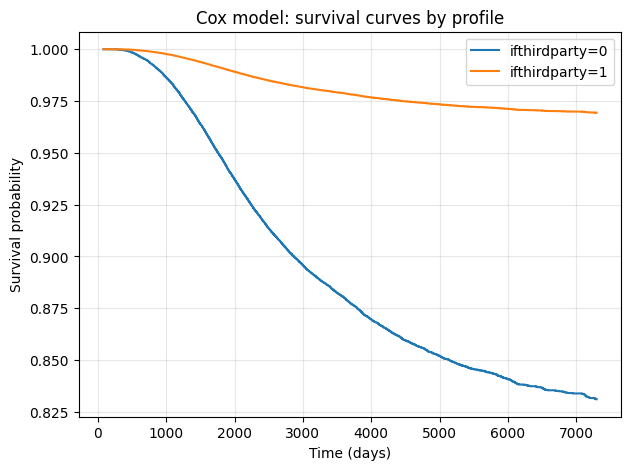

In [10]:
# Survival curves for different covariate profiles
fig, ax = plt.subplots(figsize=(7, 5))
mean_cov = df_cox[selected_features].mean()
# Baseline
surv_baseline = cox_final.predict_survival_function(mean_cov.to_frame().T)
# ax.step(surv_baseline.index, surv_baseline.iloc[:, 0], where='post', label='Baseline (mean)')
explore_col = 'ifthirdparty'
if explore_col in selected_features:
    p0 = mean_cov.copy(); p0[explore_col] = 0
    p1 = mean_cov.copy(); p1[explore_col] = 1
    s0 = cox_final.predict_survival_function(p0.to_frame().T); ax.step(s0.index, s0.iloc[:, 0], where='post', label=f'{explore_col}=0')
    s1 = cox_final.predict_survival_function(p1.to_frame().T); ax.step(s1.index, s1.iloc[:, 0], where='post', label=f'{explore_col}=1')
ax.legend()
ax.set_xlabel('Time (days)')
ax.set_ylabel('Survival probability')
ax.set_title('Cox model: survival curves by profile')
ax.grid(True, alpha=0.3)
plt.savefig(f"../figures/Cox_survival_curve_ifthirdparty.png", dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# Build test set for Cox (align columns with selected_features)
df_cox_test = df_test[['duration_days', event_col]].copy()
for c in selected_features:
    df_cox_test[c] = df_test[c] if c in df_test.columns else 0
df_cox_test = df_cox_test[selected_features + ['duration_days', event_col]]

Test Horizon 365d (1yr): AUC = 0.7057 | n = 51575
Test Horizon 1095d (3yr): AUC = 0.5453 | n = 38411
Test Horizon 1825d (5yr): AUC = 0.5496 | n = 20926
Test Horizon 2555d (7yr): AUC = 0.5496 | n = 9921
Test Horizon 3650d (10yr): AUC = 0.6752 | n = 961


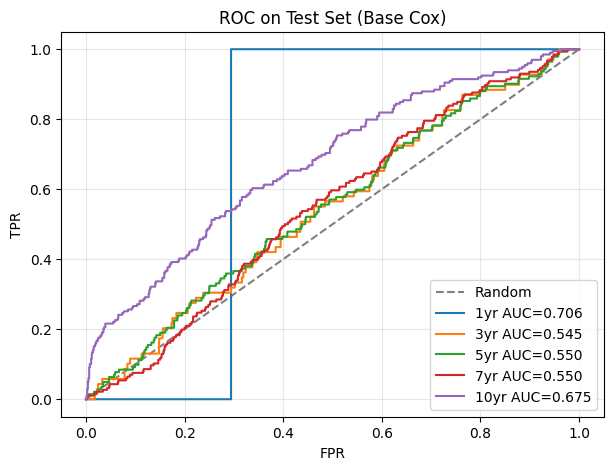

In [ ]:
def survival_roc_auc(model, X, duration, event, horizon_days, ax=None):

    surv_df = model.predict_survival_function(X, times=[horizon_days])
    y_pred = 1 - surv_df.values.flatten()

    duration = np.asarray(duration)
    event = np.asarray(event)

    mask = (duration > horizon_days) | ((event == 1) & (duration <= horizon_days))

    y_true = ((event == 1) & (duration <= horizon_days)).astype(int)

    y_true_masked = y_true[mask]
    y_pred_masked = y_pred[mask]

    fpr, tpr, _ = roc_curve(y_true_masked, y_pred_masked)
    auc = roc_auc_score(y_true_masked, y_pred_masked)

    if ax is not None:
        ax.plot(fpr, tpr, label=f'{horizon_days//365}yr AUC={auc:.3f}')
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend()
        ax.grid(True, alpha=0.3)

    return fpr, tpr, auc

# ROC and AUC on TEST set (cox_final predicts test)
X_cox_test = df_cox_test[selected_features]
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
for h in [365*1, 365*3, 365*5, 365*7, 365*10]:  # 1yr, 3yr, 5yr, 7yr, 10yr
    fpr, tpr, auc = survival_roc_auc(cox_final, X_cox_test, df_cox_test['duration_days'], df_cox_test[event_col], h, ax=ax)
    n_used = ((df_cox_test[event_col]==1) | ((df_cox_test[event_col]==0) & (df_cox_test['duration_days']>=h))).sum()
    print(f'Test Horizon {h}d ({h//365}yr): AUC = {auc:.4f} | n = {n_used}')
ax.set_title('ROC on Test Set (Base Cox)')
plt.legend()
plt.savefig(f"../figures/Cox_base_roc.png", dpi=300, bbox_inches='tight')
plt.show()

In [13]:
# Concordance index
print("Concordance Index")
print(f"  Train/Val: {cox_final.concordance_index_:.4f}")
pred_test = cox_final.predict_partial_hazard(df_cox_test[selected_features])
ci_test = concordance_index(df_cox_test['duration_days'], -pred_test, df_cox_test[event_col])
print(f"  Test: {ci_test:.4f}")

Concordance Index
  Train/Val: 0.7147
  Test: 0.5684


### Time to Pay in Full

This part is only for feature selection, which will be used in time-varying survival model to reduce the time complexity.

In [17]:
event_col = 'event_payinfull'

# Cox model: exclude duration, event, default from predictors
exclude = ['duration_days', 'event', 'default', 'event_default', 'event_payinfull']
tv_cols = [col for col in df_train_val.columns if '_m' not in col and '_y' not in col and '_st' not in col]
cox_cols = [c for c in df_train_val.columns if c not in exclude and c in tv_cols]
df_cox = df_train_val[cox_cols + ['duration_days', event_col]].copy()

# Cox model: exclude duration, event, default from predictors
cox_l1 = CoxPHFitter(penalizer=0.025, l1_ratio=1.0)
cox_l1.fit(df_cox, duration_col='duration_days', event_col=event_col)

coef = cox_l1.params_
selected_features = coef[coef.abs() > 1e-5].index.tolist()
print("Selected features:", selected_features)

Selected features: ['terminmonths', 'log_grossapproval', 'thirdparty_ratio', 'repeat_borrower', 'l2locid_count', 'naicscode_62', 'naicscode_Unknown', 'collateralind_Unknown']


## Time-Varying Survival Model

In [3]:
# ---- Time-varying Cox model (use data_tv_*) ----
df_tv_train_val = pd.read_parquet('../data/data_tv_train_val.parquet')
df_tv_test = pd.read_parquet('../data/data_tv_test.parquet')

print(f"TV Train/Val rows: {len(df_tv_train_val):,} | loans: {df_tv_train_val['loan_id'].nunique():,} | defaults: {(df_tv_train_val['event_t']==1).sum():,} | payinfulls: {(df_tv_train_val['event_t']==2).sum():,}")
print(f"TV Test rows: {len(df_tv_test):,} | loans: {df_tv_test['loan_id'].nunique():,} | defaults: {(df_tv_test['event_t']==1).sum():,} | payinfulls: {(df_tv_test['event_t']==2).sum():,}")

TV Train/Val rows: 14,489,833 | loans: 125,027 | defaults: 11,630 | payinfulls: 99,254
TV Test rows: 2,990,679 | loans: 57,399 | defaults: 199 | payinfulls: 11,181


In [5]:
# Use the covariates selected in the previous selection
sel_cols_default = ['ifthirdparty', 'log_grossapproval', 'borrstate_CA', 'borrstate_FL', 'naicscode_44', 
                    'naicscode_62', 'naicscode_72', 'naicscode_Unknown']
sel_cols_full = ['terminmonths', 'log_grossapproval', 'thirdparty_ratio', 'repeat_borrower', 'l2locid_count', 
                 'naicscode_62', 'naicscode_Unknown', 'collateralind_Unknown']

tv_cols = ['GDP_growth_y_st', 'CPI_growth_m', 'crime_rate_m_st', 'crime_rate_growth_m_st', 
           'EHE_m_st', 'EHE_growth_m_st', 'HPI_m', 'HPI_growth_m', 'PPI_m', 'PPI_growth_m',
           'unemp_m_st', 'unemp_growth_m_st', 'sp500_ret_m', 'vix_m', 'tnx_m',
           't2y_m', 'russell2000_ret_m', 'yield_spread_m']
feat_cols_default = tv_cols + sel_cols_default
feat_cols_full = tv_cols + sel_cols_full

In [4]:
def prepare_tv_df(df, event, feature_cols=None, fill_map=None):
    x = df.copy()

    # lifelines requires numeric start/stop/event
    x['month_start'] = pd.to_numeric(x['month_start'], errors='coerce')
    x['month_stop'] = pd.to_numeric(x['month_stop'], errors='coerce')
    # if event=1, model "ChangeOff"; if event=2, model "PayInFull"
    x['event_t'] = (x['event_t'] == event).astype(int)

    # drop rows with invalid interval
    x = x.dropna(subset=['loan_id', 'month_start', 'month_stop'])
    x = x[x['month_stop'] > x['month_start']].copy()

    # columns that are not covariates
    non_covariates = {
        'loan_id', 'month_start', 'month_stop', 'event_t',
        'event', 'default', 'calendar_month'
    }

    if feature_cols is None:
        candidate_cols = [c for c in x.columns if c not in non_covariates]

        # keep numeric/bool only
        feature_cols = []
        for c in candidate_cols:
            if pd.api.types.is_bool_dtype(x[c]):
                x[c] = x[c].astype(int)
                feature_cols.append(c)
            elif pd.api.types.is_numeric_dtype(x[c]):
                feature_cols.append(c)

        # remove zero-variance columns
        keep_cols = []
        for c in feature_cols:
            if x[c].nunique(dropna=True) > 1:
                keep_cols.append(c)
        feature_cols = keep_cols

    else:
        # align to training columns for test/inference
        for c in [ff for ff in feature_cols if ff not in non_covariates]:
            if c not in x.columns:
                x[c] = np.nan
            if pd.api.types.is_bool_dtype(x[c]):
                x[c] = x[c].astype(int)
            x[c] = pd.to_numeric(x[c], errors='coerce')

    model_cols = ['loan_id', 'month_start', 'month_stop', 'event_t'] + feature_cols
    tv_df = x[model_cols].copy()

    # clean inf / missing
    tv_df[feature_cols] = tv_df[feature_cols].replace([np.inf, -np.inf], np.nan)

    if fill_map is None:
        fill_map = tv_df[feature_cols].median(numeric_only=True)
    tv_df[feature_cols] = tv_df[feature_cols].fillna(fill_map)

    return tv_df, feature_cols, fill_map

In [6]:
def fit_cox_tv(event, feature_cols):
    if event == 1:
        print("---Fitting time to default Cox model---")
    elif event == 2:
        print("---Fitting time to payinfull Cox model---")
    else:
        raise ValueError("Please input a valid event number.")
    
    train_tv_pool, tv_pool_features, tv_pool_fill_map = prepare_tv_df(df_tv_train_val, event=event, feature_cols=feature_cols)
    print(f"TV candidate feature count: {len(tv_pool_features)}")
    
    # 1) L1 model for variable selection
    l1_penalty = 0.005
    ctv_l1 = CoxTimeVaryingFitter(penalizer=l1_penalty, l1_ratio=1.0)
    try:
        ctv_l1.fit(
            train_tv_pool,
            id_col='loan_id',
            start_col='month_start',
            stop_col='month_stop',
            event_col='event_t',
            show_progress=True
        )
    except Exception as e:
        print(f'L1 fit failed at penalizer={l1_penalty}. Retry with stronger penalty... ({e})')
        l1_penalty = 0.01
        ctv_l1 = CoxTimeVaryingFitter(penalizer=l1_penalty, l1_ratio=1.0)
        ctv_l1.fit(
            train_tv_pool,
            id_col='loan_id',
            start_col='month_start',
            stop_col='month_stop',
            event_col='event_t',
            show_progress=True
        )
    coef_l1 = ctv_l1.params_.copy()
    selected_tv_features = coef_l1[coef_l1.abs() > 1e-6].index.tolist()
    # Fallback: if L1 shrinks too aggressively
    if len(selected_tv_features) < 5:
        selected_tv_features = coef_l1.abs().sort_values(ascending=False).head(min(10, len(coef_l1))).index.tolist()
    print(f"Selected TV features ({len(selected_tv_features)}):")
    print(selected_tv_features)

    # 2) Refit final TV model with selected features
    train_tv_sel, _, tv_fill_map_sel = prepare_tv_df(df_tv_train_val, event=event, feature_cols=selected_tv_features)

    ctv_final = CoxTimeVaryingFitter(penalizer=0.01)
    ctv_final.fit(
        train_tv_sel,
        id_col='loan_id',
        start_col='month_start',
        stop_col='month_stop',
        event_col='event_t',
        show_progress=True
    )

    # Keep the same variable name for downstream cells
    ctv = ctv_final
    tv_features = selected_tv_features
    tv_fill_map = tv_fill_map_sel
    
    return ctv, tv_features, tv_fill_map

In [ ]:
def plot_tv_cox_diagnostics(ctv, model_name, fig_name, figsize_hazard=(7, 5), figsize_coef=(8, 4)):
    # Baseline cumulative hazard
    fig1, ax1 = plt.subplots(figsize=figsize_hazard)
    ctv.baseline_cumulative_hazard_.plot(ax=ax1, legend=False)
    ax1.set_title(f'{model_name}: baseline cumulative hazard')
    ax1.set_xlabel('Time (month)')
    ax1.set_ylabel('Cumulative hazard')
    ax1.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"../figures/{fig_name}_baseline_hazard.png", dpi=300, bbox_inches='tight')
    plt.show()

    # Coefficient plot
    coef_plot = ctv.summary[['coef']].copy().sort_values('coef')
    fig2, ax2 = plt.subplots(figsize=figsize_coef)
    ax2.barh(coef_plot.index, coef_plot['coef'])
    ax2.axvline(0, color='black', linewidth=1)
    ax2.set_title(f'{model_name}: selected coefficients')
    ax2.set_xlabel('Coefficient')
    plt.tight_layout()
    plt.savefig(f"../figures/{fig_name}_coef.png", dpi=300, bbox_inches='tight')
    plt.show()

### Time to Default

In [7]:
ctv_default, tv_feat_default, tv_fill_map_default = fit_cox_tv(event=1, feature_cols=feat_cols_default)

---Fitting time to default Cox model---
TV candidate feature count: 26
Iteration 1: norm_delta = 1.86e-01, step_size = 0.9500, log_lik = -1873238.39337, newton_decrement = 1.50e+03, seconds_since_start = 30.6
Iteration 2: norm_delta = 4.03e-02, step_size = 0.9500, log_lik = -1291918.32446, newton_decrement = 9.23e+01, seconds_since_start = 61.3
Iteration 3: norm_delta = 4.02e-02, step_size = 0.9500, log_lik = -905398.08645, newton_decrement = 1.30e+02, seconds_since_start = 92.2
Iteration 4: norm_delta = 3.27e-02, step_size = 1.0000, log_lik = -647705.11462, newton_decrement = 1.11e+02, seconds_since_start = 124.4
Iteration 5: norm_delta = 2.25e-02, step_size = 1.0000, log_lik = -475904.78522, newton_decrement = 7.56e+01, seconds_since_start = 155.6
Iteration 6: norm_delta = 1.61e-02, step_size = 1.0000, log_lik = -361384.30966, newton_decrement = 5.65e+01, seconds_since_start = 186.8
Iteration 7: norm_delta = 1.13e-02, step_size = 1.0000, log_lik = -285038.73919, newton_decrement = 4.

In [8]:
ctv_default.print_summary()
display(ctv_default.summary[['coef', 'exp(coef)', 'p']].sort_values('p').head(20))

<lifelines.CoxTimeVaryingFitter: fitted with 14489833 periods, 125027 subjects, 11630 events>
         event col = 'event_t'
number of subjects = 125027
 number of periods = 14489833
  number of events = 11630
partial log-likelihood = -126945.96
  time fit was run = 2026-03-23 11:53:23 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
naicscode_72       0.77      2.15      0.02            0.72            0.81                2.05                2.25
ifthirdparty      -2.03      0.13      0.04           -2.11           -1.96                0.12                0.14
borrstate_FL       0.57      1.77      0.03            0.51            0.63                1.66                1.88
unemp_m_st         0.20      1.22      0.01            0.18            0.22                1.19                1.24
naicscode_Unknown  0.10      1.10      0.04            0.02            0.17                1.02                1.19
t2y_m             -0.20      0.82      0.03           -0.25           -0.15                0.78                0.86
naicscode_62      -0.51      0.60      0.04           -0.58           -0.43                0.56                0.65
naicscode_44       0.35      1.42      0.03            0.29            0.41                1.34                1.51
tnx_m             -0.60      0.55      0.02           -0.64           -0.56                0.52                0.57
GDP_growth_y_st   -0.02      0.98      0.01           -0.05           -0.00                0.96                1.00

                   cmp to      z      p  -log2(p)
covariate                                        
naicscode_72         0.00  32.29 <0.005    757.45
ifthirdparty         0.00 -51.86 <0.005       inf
borrstate_FL         0.00  17.75 <0.005    231.69
unemp_m_st           0.00  18.95 <0.005    263.50
naicscode_Unknown    0.00   2.54   0.01      6.49
t2y_m                0.00  -7.90 <0.005     48.36
naicscode_62         0.00 -13.75 <0.005    140.55
naicscode_44         0.00  11.74 <0.005    103.37
tnx_m                0.00 -29.33 <0.005    625.76
GDP_growth_y_st      0.00  -2.07   0.04      4.71
---
Partial AIC = 253911.92
log-likelihood ratio test = 10808.08 on 10 df
-log2(p) of ll-ratio test = inf

,coef,exp(coef),p
covariate,,,
ifthirdparty,-2.033904,0.130824,0.000000e+00
naicscode_72,0.765336,2.149717,9.678139e-229
tnx_m,-0.604407,0.546399,4.232973e-189
unemp_m_st,0.195814,1.216301,4.780257e-80
borrstate_FL,0.569109,1.766692,1.800627e-70
naicscode_62,-0.505433,0.603244,4.884963e-43
naicscode_44,0.351851,1.421697,7.637188e-32
t2y_m,-0.198517,0.819945,2.773574e-15
naicscode_Unknown,0.097650,1.102577,1.110232e-02


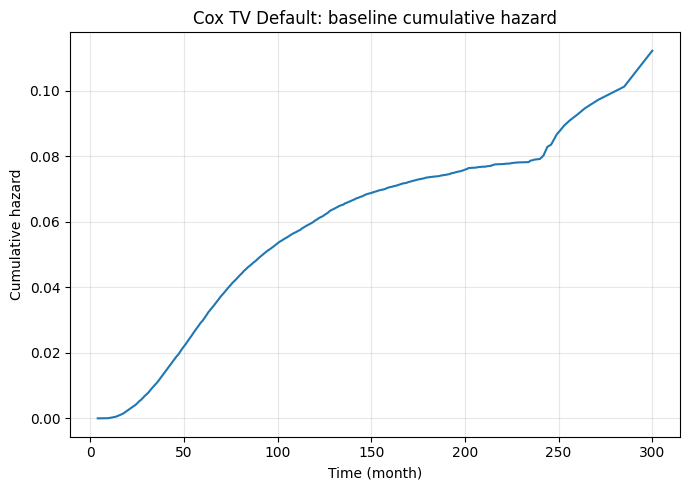

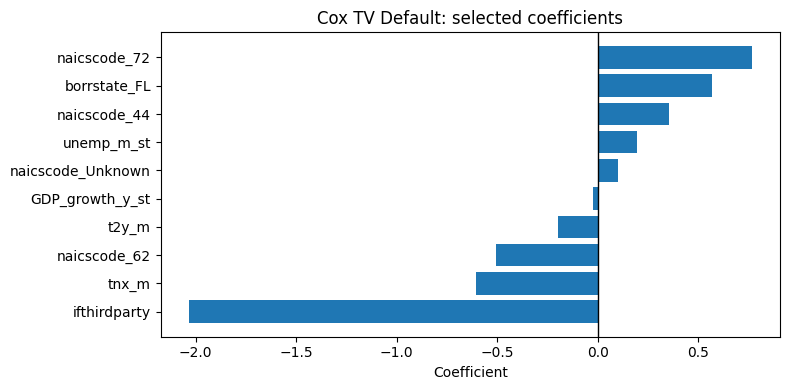

In [ ]:
plot_tv_cox_diagnostics(ctv_default, model_name="Cox TV Default", fig_name="Cox_tv_default")

In [ ]:
# Re-evaluate selected-feature TV model: C-index + ROC/AUC
test_tv_sel, _, _ = prepare_tv_df(
    df_tv_test, event=1,
    feature_cols=tv_feat_default,
    fill_map=tv_fill_map_default
)

pred_risk_interval_sel = ctv_default.predict_partial_hazard(test_tv_sel).values.ravel()

# C-index (interval level)
ci_interval_sel = concordance_index(
    test_tv_sel['month_stop'],
    -pred_risk_interval_sel,
    test_tv_sel['event_t']
)

# C-index (loan last interval)
test_eval_sel = test_tv_sel[['loan_id', 'month_stop', 'event_t']].copy()
test_eval_sel['risk_score'] = pred_risk_interval_sel
loan_last_sel = test_eval_sel.sort_values(['loan_id', 'month_stop']).groupby('loan_id', as_index=False).tail(1)
ci_loan_last_sel = concordance_index(
    loan_last_sel['month_stop'],
    -loan_last_sel['risk_score'],
    loan_last_sel['event_t']
)

print('TV Cox (selected features) Concordance Index')
print(f"  Interval-level C-index: {ci_interval_sel:.4f}")
print(f"  Loan-last-interval C-index: {ci_loan_last_sel:.4f}")

TV Cox (selected features) Concordance Index
  Interval-level C-index: 0.6511
  Loan-last-interval C-index: 0.7048


TV (selected) Test Horizon 12m (1yr): AUC = 0.9302 | n = 51910
TV (selected) Test Horizon 36m (3yr): AUC = 0.6976 | n = 38828
TV (selected) Test Horizon 60m (5yr): AUC = 0.7293 | n = 21301
TV (selected) Test Horizon 84m (7yr): AUC = 0.6924 | n = 10235
TV (selected) Test Horizon 120m (10yr): AUC = 0.7443 | n = 1092


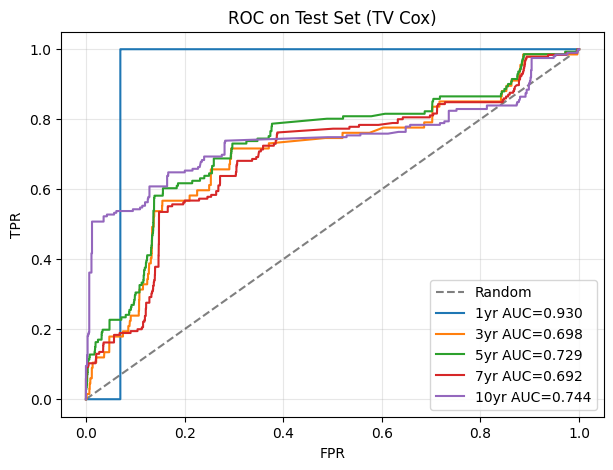

In [ ]:
def tv_roc_auc_selected(risk_df, horizon_months, ax=None):
    duration = risk_df['duration_months'].to_numpy()
    event = risk_df['event'].to_numpy().astype(int)
    y_pred = risk_df['risk_score'].to_numpy()

    mask = ((event == 1) & (duration <= horizon_months)) | ((event == 0) & (duration >= horizon_months))
    y_true = ((event == 1) & (duration <= horizon_months)).astype(int)

    y_true_masked = y_true[mask]
    y_pred_masked = y_pred[mask]

    fpr, tpr, _ = roc_curve(y_true_masked, y_pred_masked)
    auc = roc_auc_score(y_true_masked, y_pred_masked)

    if ax is not None:
        ax.plot(fpr, tpr, label=f'{horizon_months/12:.0f}yr AUC={auc:.3f}')

    return fpr, tpr, auc, int(mask.sum())


risk_loan_sel = loan_last_sel.rename(columns={'month_stop': 'duration_months', 'event_t': 'event'}).copy()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')

for h_m in [12 * 1, 12 * 3, 12 * 5, 12 * 7, 12 * 10]:
    fpr, tpr, auc, n_used = tv_roc_auc_selected(risk_loan_sel, h_m, ax=ax)
    if np.isnan(auc):
        print(f'TV (selected) Test Horizon {h_m}m ({h_m/12:.0f}yr): AUC undefined (single class) | n = {n_used}')
    else:
        print(f'TV (selected) Test Horizon {h_m}m ({h_m/12:.0f}yr): AUC = {auc:.4f} | n = {n_used}')

ax.set_title('ROC on Test Set (TV Cox)')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig(f"../figures/Cox_tv_default_roc.png", dpi=300, bbox_inches='tight')
plt.show()

### Time to Pay in Full

In [ ]:
ctv_full, tv_feat_full, tv_fill_map_full = fit_cox_tv(event=2, feature_cols=feat_cols_full)

---Fitting time to payinfull Cox model---
TV candidate feature count: 26
Iteration 1: norm_delta = 4.13e-01, step_size = 0.9500, log_lik = -2811646.59554, newton_decrement = 1.23e+04, seconds_since_start = 33.2
Iteration 2: norm_delta = 8.52e-02, step_size = 0.9500, log_lik = -2226576.69963, newton_decrement = 3.37e+03, seconds_since_start = 66.6
Iteration 3: norm_delta = 7.85e-02, step_size = 0.9500, log_lik = -1838168.24250, newton_decrement = 1.12e+03, seconds_since_start = 100.3
Iteration 4: norm_delta = 6.39e-02, step_size = 1.0000, log_lik = -1581139.69346, newton_decrement = 5.78e+02, seconds_since_start = 134.4
Iteration 5: norm_delta = 4.82e-02, step_size = 1.0000, log_lik = -1410412.08486, newton_decrement = 4.18e+02, seconds_since_start = 168.7
Iteration 6: norm_delta = 3.98e-02, step_size = 1.0000, log_lik = -1296932.68890, newton_decrement = 3.84e+02, seconds_since_start = 202.7
Iteration 7: norm_delta = 3.21e-02, step_size = 1.0000, log_lik = -1221420.68717, newton_decrem

In [ ]:
ctv_full.print_summary()
display(ctv_full.summary[['coef', 'exp(coef)', 'p']].sort_values('p').head(20))

<lifelines.CoxTimeVaryingFitter: fitted with 14489833 periods, 125027 subjects, 99254 events>
         event col = 'event_t'
number of subjects = 125027
 number of periods = 14489833
  number of events = 99254
partial log-likelihood = -1056883.28
  time fit was run = 2026-03-23 12:25:56 UTC

---
                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                              
repeat_borrower       -1.76      0.17      0.02           -1.80           -1.73                0.17                0.18
collateralind_Unknown  0.63      1.88      0.01            0.61            0.65                1.85                1.91
vix_m                 -0.38      0.68      0.00           -0.39           -0.37                0.68                0.69
russell2000_ret_m     -0.34      0.71      0.00           -0.35           -0.33                0.71                0.72
HPI_growth_m           0.08      1.09      0.00            0.08            0.09                1.08                1.10
PPI_growth_m           0.16      1.18      0.00            0.16            0.17                1.17                1.19
naicscode_62          -0.09      0.91      0.01           -0.11           -0.07                0.90                0.93
CPI_growth_m          -0.03      0.97      0.00           -0.03           -0.02                0.97                0.98
GDP_growth_y_st        0.01      1.01      0.00            0.00            0.02                1.00                1.02
yield_spread_m        -0.09      0.91      0.00           -0.10           -0.08                0.91                0.92

                       cmp to       z      p  -log2(p)
covariate                                             
repeat_borrower          0.00 -108.19 <0.005       inf
collateralind_Unknown    0.00   71.21 <0.005       inf
vix_m                    0.00  -81.97 <0.005       inf
russell2000_ret_m        0.00  -84.87 <0.005       inf
HPI_growth_m             0.00   21.87 <0.005    349.81
PPI_growth_m             0.00   35.58 <0.005    918.67
naicscode_62             0.00   -8.80 <0.005     59.39
CPI_growth_m             0.00   -5.40 <0.005     23.84
GDP_growth_y_st          0.00    2.95 <0.005      8.29
yield_spread_m           0.00  -25.16 <0.005    461.55
---
Partial AIC = 2113786.55
log-likelihood ratio test = 27749.85 on 10 df
-log2(p) of ll-ratio test = inf

,coef,exp(coef),p
covariate,,,
repeat_borrower,-1.763862,0.171382,0.000000e+00
collateralind_Unknown,0.631650,1.880712,0.000000e+00
vix_m,-0.380357,0.683617,0.000000e+00
russell2000_ret_m,-0.340471,0.711435,0.000000e+00
PPI_growth_m,0.164788,1.179143,2.836938e-277
yield_spread_m,-0.089566,0.914328,1.150370e-139
HPI_growth_m,0.084316,1.087973,4.979174e-106
naicscode_62,-0.088850,0.914983,1.320251e-18
CPI_growth_m,-0.025576,0.974749,6.661842e-08


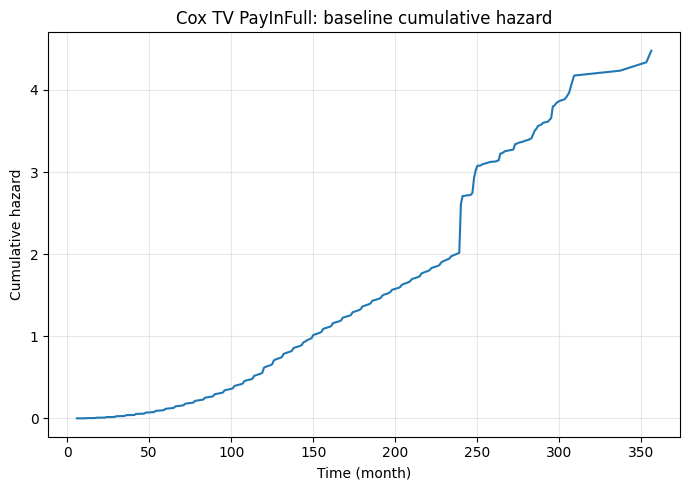

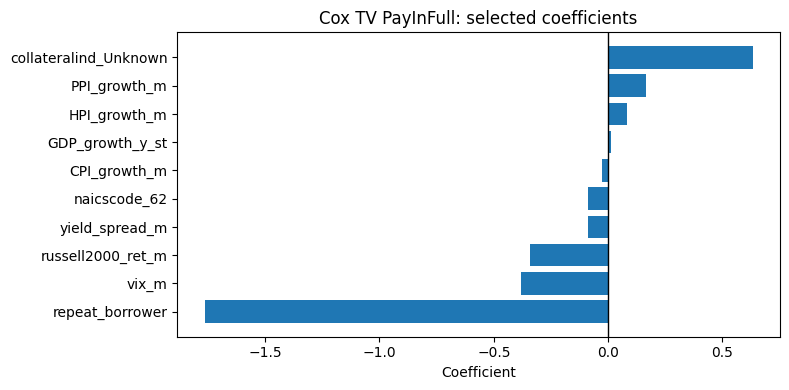

In [ ]:
plot_tv_cox_diagnostics(ctv_full, model_name="Cox TV PayInFull", fig_name="Cox_tv_payinfull")

In [ ]:
print("Final selected variables:")
print(f"  Default model ({len(tv_feat_default)}):", tv_feat_default)
print(f"  PayInFull model ({len(tv_feat_full)}):", tv_feat_full)

Final selected variables:
  Default model (10): ['naicscode_72', 'ifthirdparty', 'borrstate_FL', 'unemp_m_st', 'naicscode_Unknown', 't2y_m', 'naicscode_62', 'naicscode_44', 'tnx_m', 'GDP_growth_y_st']
  PayInFull model (10): ['repeat_borrower', 'collateralind_Unknown', 'vix_m', 'russell2000_ret_m', 'HPI_growth_m', 'PPI_growth_m', 'naicscode_62', 'CPI_growth_m', 'GDP_growth_y_st', 'yield_spread_m']
